# 🧠 SmartVision AI - Data Verification & EDA Notebook

This notebook verifies your existing dataset and performs Exploratory Data Analysis (EDA).

## IMPORTS AND CONFIGURATION

In [1]:
import os
import json
import random
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict
from tqdm import tqdm

# Set BASE_DIR - assuming data is in smartvision_data folder next to notebooks
NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR = os.path.dirname(NOTEBOOK_DIR)
BASE_DIR = os.path.join(PROJECT_DIR, 'smartvision_data')

print(f"📁 Project directory: {PROJECT_DIR}")
print(f"📁 Data directory: {BASE_DIR}")
print(f"✅ Data exists: {os.path.exists(BASE_DIR)}")

📁 Project directory: C:\Users\selvam.anandhan\OneDrive - IDP Education Ltd\Documents\DS\DS with GUVI\Guvi projects\SmartVision AI
📁 Data directory: C:\Users\selvam.anandhan\OneDrive - IDP Education Ltd\Documents\DS\DS with GUVI\Guvi projects\SmartVision AI\smartvision_data
✅ Data exists: True


### 26 Selected Classes with COCO Category IDs

**Vehicles:** car(2), truck(7), bus(5), motorcycle(3), bicycle(1), airplane(4), train(6)  
**Person:** person(0)  
**Outdoor:** traffic light(8), stop sign(9), bench(10)  
**Animals:** dog(13), cat(12), horse(14), bird(11), cow(15), elephant(16)  
**Kitchen & Food:** bottle(17), cup(18), bowl(19), pizza(20), cake(21)  
**Furniture:** chair(22), couch(23), potted plant(24), bed(25)

In [2]:
# 26 Selected Classes (for reference)
SELECTED_CLASSES = [
    'airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus',
    'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant',
    'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign',
    'traffic light', 'train', 'truck'
]

print(f"✅ {len(SELECTED_CLASSES)} classes defined")
print(f"📋 Classes: {', '.join(SELECTED_CLASSES)}")

✅ 26 classes defined
📋 Classes: airplane, bed, bench, bicycle, bird, bottle, bowl, bus, cake, car, cat, chair, couch, cow, cup, dog, elephant, horse, motorcycle, person, pizza, potted plant, stop sign, traffic light, train, truck


In [3]:
# Verify data exists
print("="*70)
print("🔍 VERIFYING EXISTING DATASET")
print("="*70)

# Check classification directories
class_dirs = ['train', 'val', 'test']
classification_stats = {}

for split in class_dirs:
    split_path = os.path.join(BASE_DIR, 'classification', split)
    if os.path.exists(split_path):
        classes = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]
        classification_stats[split] = {'classes': len(classes), 'class_names': classes}
        print(f"✅ Classification/{split}: {len(classes)} classes")
    else:
        print(f"❌ Classification/{split}: NOT FOUND")
        classification_stats[split] = {'classes': 0, 'class_names': []}

# Check detection directories
detection_images = os.path.join(BASE_DIR, 'detection', 'images')
detection_labels = os.path.join(BASE_DIR, 'detection', 'labels')

if os.path.exists(detection_images):
    num_images = len([f for f in os.listdir(detection_images) if f.endswith(('.jpg', '.png', '.jpeg'))])
    print(f"✅ Detection/images: {num_images} images")
else:
    print(f"❌ Detection/images: NOT FOUND")

if os.path.exists(detection_labels):
    num_labels = len([f for f in os.listdir(detection_labels) if f.endswith('.txt')])
    print(f"✅ Detection/labels: {num_labels} labels")
else:
    print(f"❌ Detection/labels: NOT FOUND")

print("\n✅ Dataset verification complete!")

🔍 VERIFYING EXISTING DATASET
✅ Classification/train: 26 classes
✅ Classification/val: 26 classes
✅ Classification/test: 26 classes
✅ Detection/images: 1525 images
✅ Detection/labels: 4755 labels

✅ Dataset verification complete!


## STEP 2: COUNT IMAGES PER CLASS AND SPLIT

In [20]:
# Count images per class and split
print("="*70)
print("📊 COUNTING IMAGES PER CLASS AND SPLIT")
print("="*70)

class_counts = {split: defaultdict(int) for split in ['train', 'val', 'test']}
total_images = 0

for split in ['train', 'val', 'test']:
    split_path = os.path.join(BASE_DIR, 'classification', split)
    if os.path.exists(split_path):
        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)
            if os.path.isdir(class_path):
                num_images = len([f for f in os.listdir(class_path) 
                                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.gif'))])
                class_counts[split][class_name] = num_images
                total_images += num_images

# Display summary
print(f"\n📈 Dataset Summary:")
print(f"   Total images: {total_images}")
print(f"\n{'Class':<20} | {'Train':>8} | {'Val':>6} | {'Test':>6} | {'Total':>6}")
print("-" * 60)

for class_name in sorted(class_counts['train'].keys()):
    train_count = class_counts['train'][class_name]
    val_count = class_counts['val'].get(class_name, 0)
    test_count = class_counts['test'].get(class_name, 0)
    total = train_count + val_count + test_count
    print(f"{class_name:<20} | {train_count:>8} | {val_count:>6} | {test_count:>6} | {total:>6}")

# Totals row
train_total = sum(class_counts['train'].values())
val_total = sum(class_counts['val'].values())
test_total = sum(class_counts['test'].values())
print("-" * 60)
print(f"{'TOTAL':<20} | {train_total:>8} | {val_total:>6} | {test_total:>6} | {total_images:>6}")

📊 COUNTING IMAGES PER CLASS AND SPLIT

📈 Dataset Summary:
   Total images: 13000

Class                |    Train |    Val |   Test |  Total
------------------------------------------------------------
airplane             |      350 |     75 |     75 |    500
bed                  |      350 |     75 |     75 |    500
bench                |      350 |     75 |     75 |    500
bicycle              |      350 |     75 |     75 |    500
bird                 |      350 |     75 |     75 |    500
bottle               |      350 |     75 |     75 |    500
bowl                 |      350 |     75 |     75 |    500
bus                  |      350 |     75 |     75 |    500
cake                 |      350 |     75 |     75 |    500
car                  |      350 |     75 |     75 |    500
cat                  |      350 |     75 |     75 |    500
chair                |      350 |     75 |     75 |    500
couch                |      350 |     75 |     75 |    500
cow                  |      350

## STEP 3: VERIFY DETECTION DATA (YOLO FORMAT)

In [5]:
# Verify detection data (YOLO format)
print("="*70)
print("🔍 VERIFYING DETECTION DATA (YOLO FORMAT)")
print("="*70)

detection_images_dir = os.path.join(BASE_DIR, 'detection', 'images')
detection_labels_dir = os.path.join(BASE_DIR, 'detection', 'labels')

# Count images and labels
image_files = []
label_files = []

if os.path.exists(detection_images_dir):
    image_files = [f for f in os.listdir(detection_images_dir) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
if os.path.exists(detection_labels_dir):
    label_files = [f for f in os.listdir(detection_labels_dir) 
                   if f.endswith('.txt')]

print(f"\n📊 Detection Dataset:")
print(f"   Images: {len(image_files)}")
print(f"   Labels: {len(label_files)}")

# Sample label file check
if label_files:
    sample_label = os.path.join(detection_labels_dir, label_files[0])
    with open(sample_label, 'r') as f:
        sample_content = f.read()
    print(f"\n📄 Sample label (first file):")
    print(f"   {label_files[0]}")
    print(f"   Content:\n{sample_content[:200]}")

# Count objects per class
class_object_counts = defaultdict(int)
for label_file in label_files:
    label_path = os.path.join(detection_labels_dir, label_file)
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_id = int(parts[0])
                class_object_counts[class_id] += 1

print(f"\n📈 Objects per class (YOLO ID):")
for class_id, count in sorted(class_object_counts.items()):
    class_name = SELECTED_CLASSES[class_id] if class_id < len(SELECTED_CLASSES) else f"class_{class_id}"
    print(f"   {class_id}: {class_name:<15} -> {count} objects")

🔍 VERIFYING DETECTION DATA (YOLO FORMAT)

📊 Detection Dataset:
   Images: 1525
   Labels: 4755

📄 Sample label (first file):
   image_000000.txt
   Content:
2 0.683563 0.866652 0.575156 0.639781
2 0.317188 0.781193 0.280938 0.563567
2 0.035977 0.743611 0.071953 0.543807
0 0.990680 0.855295 0.681891 0.667790
0 0.234047 0.968260 0.217625 0.847112
0 0.436000

📈 Objects per class (YOLO ID):
   0: airplane        -> 9913 objects
   1: bed             -> 581 objects
   2: bench           -> 2864 objects
   3: bicycle         -> 566 objects
   4: bird            -> 472 objects
   5: bottle          -> 516 objects
   6: bowl            -> 464 objects
   7: bus             -> 747 objects
   8: cake            -> 837 objects
   9: car             -> 445 objects
   10: cat             -> 573 objects
   11: chair           -> 534 objects
   12: couch           -> 463 objects
   13: cow             -> 485 objects
   14: cup             -> 495 objects
   15: dog             -> 524 objects
   16: ele

# Create the in and Validation txt file for train the model

In [6]:
import os
import random

images_dir = os.path.join(BASE_DIR, "detection", "images")
labels_dir = os.path.join(BASE_DIR, "detection", "labels")

# Get all image filenames
all_image_filenames = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Shuffle filenames for random split
random.shuffle(all_image_filenames)

# Define split ratio (e.g., 80% train, 20% validation)
split_ratio = 0.8
split_index = int(len(all_image_filenames) * split_ratio)

train_files_rel = [os.path.join('images', f) for f in all_image_filenames[:split_index]]
val_files_rel = [os.path.join('images', f) for f in all_image_filenames[split_index:]]

# Create train.txt and val.txt files with relative paths
train_list_path = os.path.join(BASE_DIR, "detection", "train.txt")
val_list_path = os.path.join(BASE_DIR, "detection", "val.txt")

with open(train_list_path, 'w') as f:
    for img_rel_path in train_files_rel:
        f.write(img_rel_path + '\n')

with open(val_list_path, 'w') as f:
    for img_rel_path in val_files_rel:
        f.write(img_rel_path + '\n')

print(f"✅ Detection dataset split into train.txt ({len(train_files_rel)} images) and val.txt ({len(val_files_rel)} images).")
print(f"   Train list saved to: {train_list_path}")
print(f"   Validation list saved to: {val_list_path}")


✅ Detection dataset split into train.txt (1220 images) and val.txt (305 images).
   Train list saved to: C:\Users\selvam.anandhan\OneDrive - IDP Education Ltd\Documents\DS\DS with GUVI\Guvi projects\SmartVision AI\smartvision_data\detection\train.txt
   Validation list saved to: C:\Users\selvam.anandhan\OneDrive - IDP Education Ltd\Documents\DS\DS with GUVI\Guvi projects\SmartVision AI\smartvision_data\detection\val.txt


# CREATE YOLO CONFIG FILE

In [24]:
print("📝 Creating YOLO configuration file...\n")

class_names_yaml = "\n".join(
    [f"  {idx}: {name}" for idx, name in enumerate(SELECTED_CLASSES)]
)

yaml_content = f"""# SmartVision Dataset - YOLOv8 Configuration
path: {os.path.abspath(BASE_DIR)}/detection
train: images
val: images

names:
{class_names_yaml}

nc: {len(SELECTED_CLASSES)}
"""

yaml_path = f"{BASE_DIR}/detection/data.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"✅ Created: {yaml_path}")

# PART D: CREATE DETECTION STATS
detection_stats = {
    'images': num_images,
    'labels': num_labels,
    'classes': len(SELECTED_CLASSES),
    'class_names': SELECTED_CLASSES,
    'objects_per_class': dict(class_object_counts)
}

print(f"\n📊 Detection Stats Created:")
print(f"   Images: {detection_stats['images']}")
print(f"   Labels: {detection_stats['labels']}")
print(f"   Classes: {detection_stats['classes']}")

📝 Creating YOLO configuration file...

✅ Created: C:\Users\selvam.anandhan\OneDrive - IDP Education Ltd\Documents\DS\DS with GUVI\Guvi projects\SmartVision AI\smartvision_data/detection/data.yaml

📊 Detection Stats Created:
   Images: 75
   Labels: 4755
   Classes: 26


# SAVE METADATA

In [ ]:
metadata = {}
metadata['classification'] = classification_stats
metadata['detection'] = detection_stats
metadata['dataset_path'] = os.path.abspath(BASE_DIR)

metadata_path = f"{BASE_DIR}/dataset_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, indent=2, fp=f)

print(f"✅ Saved metadata to: {metadata_path}")



✅ Saved metadata to: C:\Users\selvam.anandhan\OneDrive - IDP Education Ltd\Documents\DS\DS with GUVI\Guvi projects\SmartVision AI\smartvision_data/dataset_metadata.json


## EXPLORATORY DATA ANALYSIS (EDA)

🖼️ SAMPLE IMAGES FROM TRAINING SET


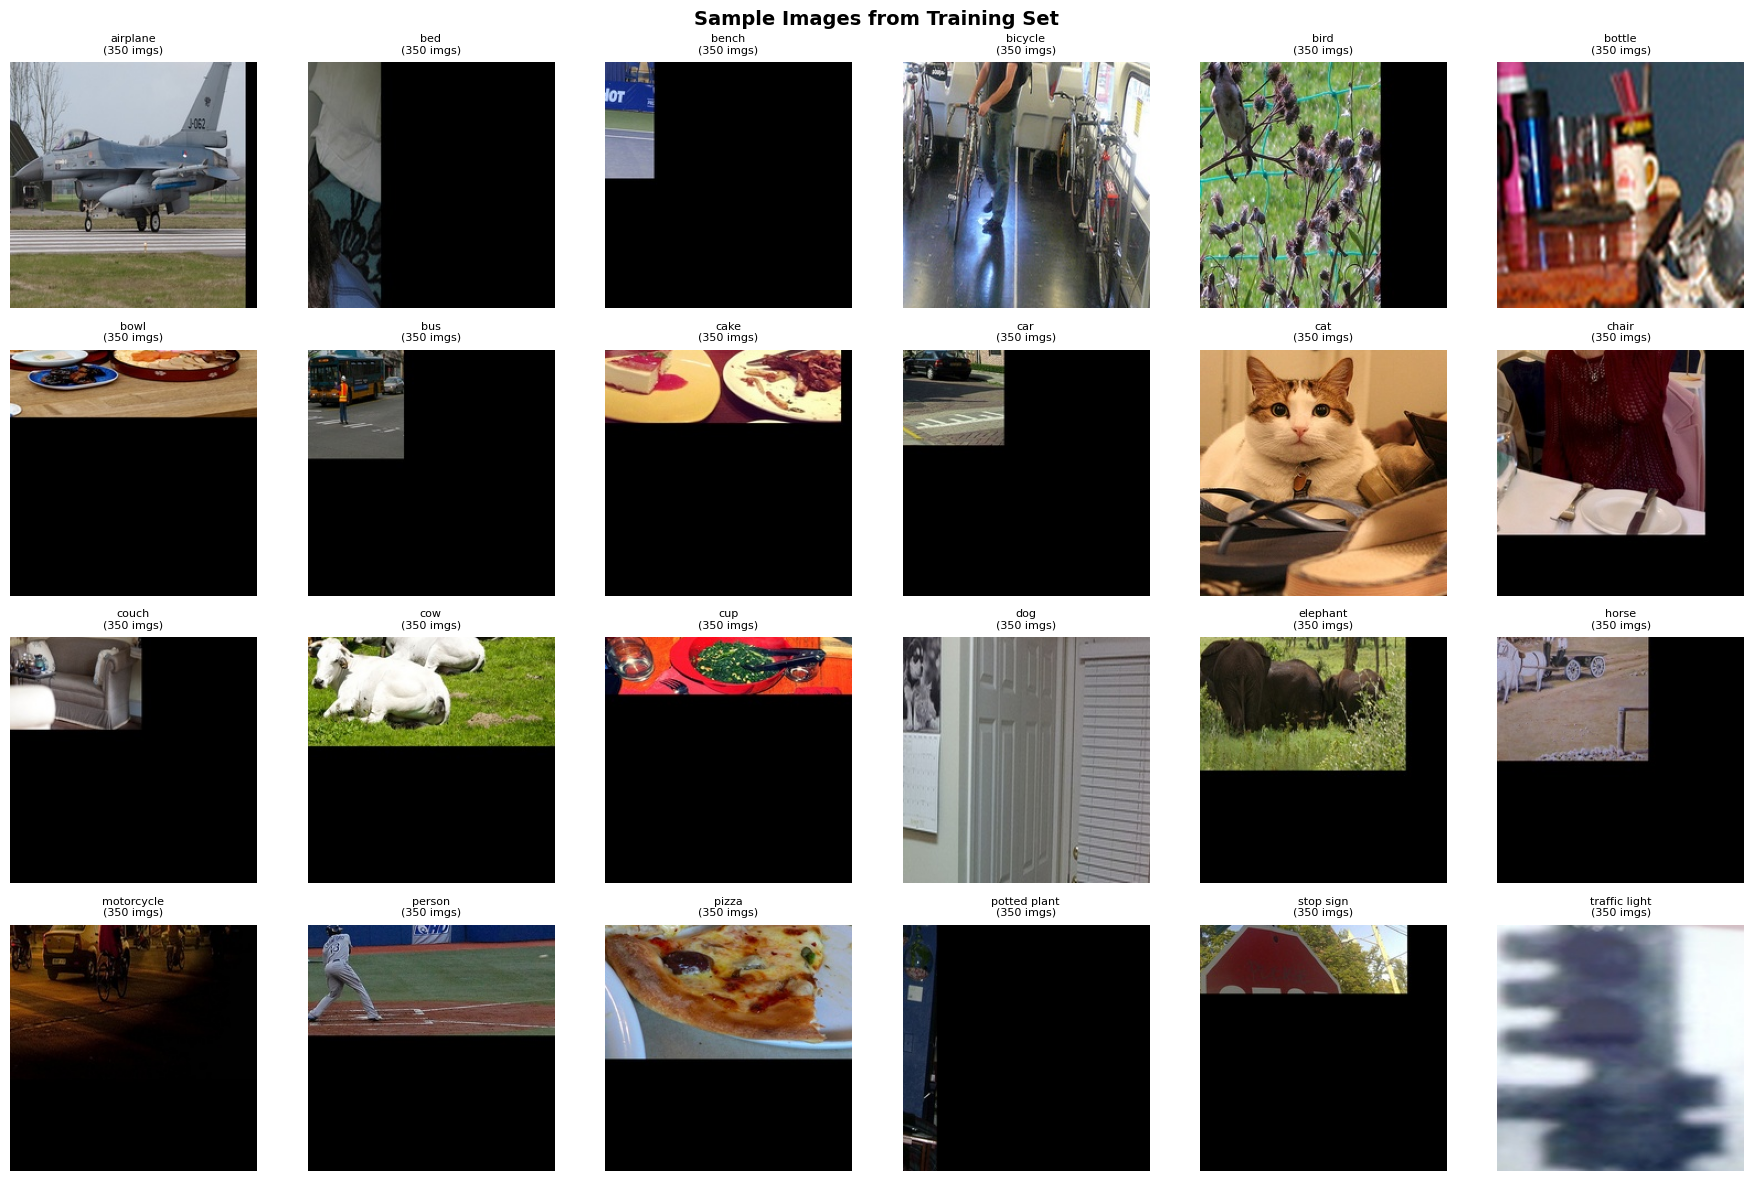

In [36]:
# Visualize sample images from each split
print("="*70)
print("🖼️ SAMPLE IMAGES FROM TRAINING SET")
print("="*70)

train_path = os.path.join(BASE_DIR, 'classification', 'train')
classes = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])

# Create figure
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
axes = axes.flatten()

for i, class_name in enumerate(classes[:24]):
    class_path = os.path.join(train_path, class_name)
    img_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if img_files:
        sample_img = random.choice(img_files)
        img = Image.open(os.path.join(class_path, sample_img))
        axes[i].imshow(img)
        axes[i].set_title(f"{class_name}\n({len(img_files)} imgs)", fontsize=8)
        axes[i].axis('off')

# Hide unused axes
for i in range(len(classes), 24):
    axes[i].axis('off')

plt.suptitle('Sample Images from Training Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()